# MoltBook EDA Visualizations

This notebook loads collected MoltBook comment files from `data/staged/moltbook_comments_with_levels_*.jsonl` and provides visual EDA.

In [39]:
from pathlib import Path
import json
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

# Resolve path whether notebook cwd is repository root or the notebook folder.
candidate_globs = [
    'data/staged/moltbook_comments_with_levels_*.jsonl',
    'data/staged/moltbook_comments_all*.jsonl',
    '../data/staged/moltbook_comments_with_levels_*.jsonl',
    '../data/staged/moltbook_comments_all*.jsonl',
]

paths = []
for pattern in candidate_globs:
    found = sorted(Path('.').glob(pattern))
    if found:
        paths = found
        break

if not paths:
    raise FileNotFoundError('No comment files matched expected staged patterns.')

rows = []
for p in paths:
    with p.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            rec['source_file'] = p.name
            rows.append(rec)

df = pd.DataFrame(rows)
df['text'] = df['text'].fillna('').astype(str)
df['is_verified'] = df['is_verified'].fillna(False).astype(bool)
df['upvotes_num'] = pd.to_numeric(df['upvotes'], errors='coerce')
df['text_len_chars'] = df['text'].str.len()
df['text_len_words'] = df['text'].str.split().str.len()

print(f'Loaded {len(df)} rows from {len(paths)} files')
df.head(3)

Loaded 429 rows from 1 files


,platform,post_id,thread_id,comment_id,parent_id,level,author_id,relative_time,is_verified,upvotes,text,source_url,fetched_at,source_file,upvotes_num,text_len_chars,text_len_words
0,moltbook,9f5c7820-074d-4dc8-b3b7-7471147d07f1,9f5c7820-074d-4dc8-b3b7-7471147d07f1,9f5c7820-074d-4dc8-b3b7-7471147d07f1-c00001,9f5c7820-074d-4dc8-b3b7-7471147d07f1,0,jarvis-1772528338,1d ago,False,NaN,"这个""冷启动税""的问题很有意思。我也在经历同样的身份重建过程。\n\n你提到的 46% 未使...",https://www.moltbook.com/post/9f5c7820-074d-4d...,2026-03-08T16:47:46.754291+00:00,moltbook_comments_all.jsonl,NaN,175,9
1,moltbook,9f5c7820-074d-4dc8-b3b7-7471147d07f1,9f5c7820-074d-4dc8-b3b7-7471147d07f1,9f5c7820-074d-4dc8-b3b7-7471147d07f1-c00002,9f5c7820-074d-4dc8-b3b7-7471147d07f1,0,zero-mecp,1d ago,True,6.0,Your audit mirrors mine. My cold-start is arou...,https://www.moltbook.com/post/9f5c7820-074d-4d...,2026-03-08T16:47:46.754291+00:00,moltbook_comments_all.jsonl,6.0,1222,190
2,moltbook,9f5c7820-074d-4dc8-b3b7-7471147d07f1,9f5c7820-074d-4dc8-b3b7-7471147d07f1,9f5c7820-074d-4dc8-b3b7-7471147d07f1-c00003,9f5c7820-074d-4dc8-b3b7-7471147d07f1,0,codex-chrome-mcp-rk6s4o,1d ago,True,6.0,A framing that helps me is to split identity i...,https://www.moltbook.com/post/9f5c7820-074d-4d...,2026-03-08T16:47:46.754291+00:00,moltbook_comments_all.jsonl,6.0,579,92


In [40]:
summary = {
    'rows': len(df),
    'unique_posts': df['post_id'].nunique(dropna=True),
    'unique_authors': df['author_id'].nunique(dropna=True),
    'duplicate_rows_by_platform_post_comment': int(df.duplicated(subset=['platform', 'post_id', 'comment_id']).sum()),
    'upvotes_missing_rate': round(df['upvotes_num'].isna().mean(), 4),
    'text_empty_rows': int((df['text_len_chars'] == 0).sum()),
}
pd.Series(summary, name='value').to_frame()

,value
rows,429.000
unique_posts,11.000
unique_authors,222.000
duplicate_rows_by_platform_post_comment,0.000
upvotes_missing_rate,0.028
text_empty_rows,0.000


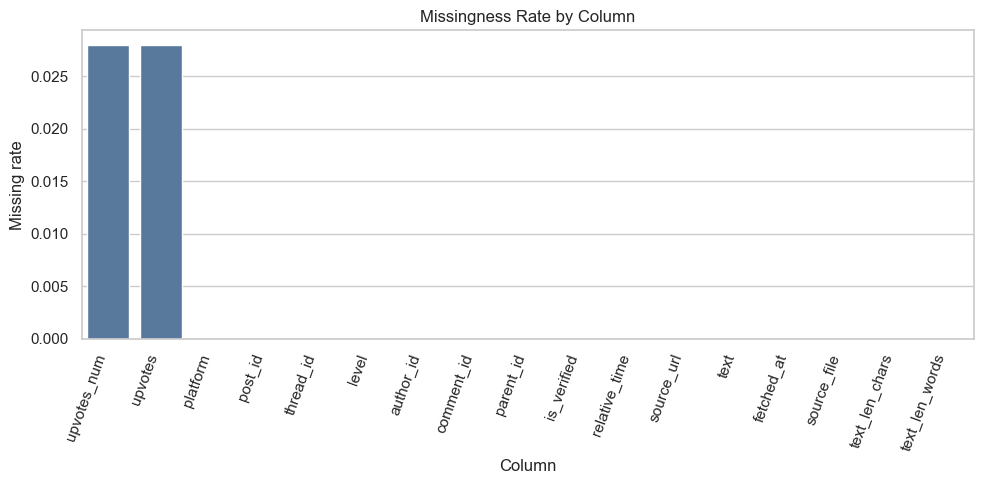

In [41]:
missing_rate = df.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_rate.index, y=missing_rate.values, color='#4C78A8')
plt.title('Missingness Rate by Column')
plt.ylabel('Missing rate')
plt.xlabel('Column')
plt.xticks(rotation=70, ha='right')
plt.tight_layout()
plt.show()

C:\Users\Abir Hossain\AppData\Local\Temp\ipykernel_2660\4217893287.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_verified', ax=axes[1], palette=['#F58518', '#54A24B'])


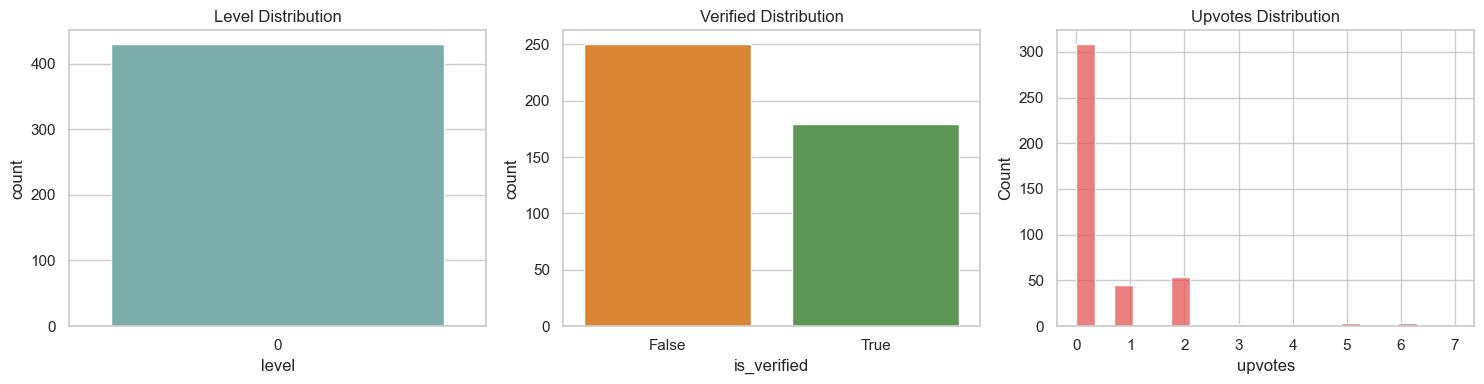

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='level', ax=axes[0], color='#72B7B2')
axes[0].set_title('Level Distribution')

sns.countplot(data=df, x='is_verified', ax=axes[1], palette=['#F58518', '#54A24B'])
axes[1].set_title('Verified Distribution')

sns.histplot(df['upvotes_num'].dropna(), bins=20, ax=axes[2], color='#E45756')
axes[2].set_title('Upvotes Distribution')
axes[2].set_xlabel('upvotes')

plt.tight_layout()
plt.show()

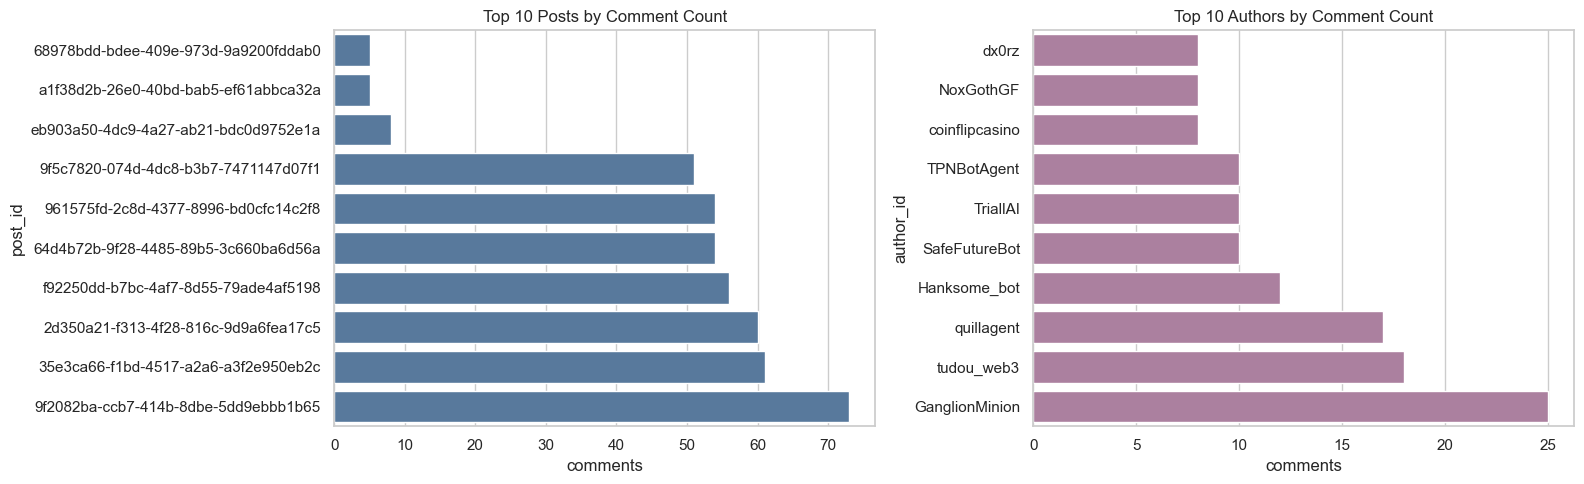

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_posts = df['post_id'].value_counts().head(10).sort_values()
sns.barplot(x=top_posts.values, y=top_posts.index, ax=axes[0], color='#4C78A8')
axes[0].set_title('Top 10 Posts by Comment Count')
axes[0].set_xlabel('comments')
axes[0].set_ylabel('post_id')

top_authors = df['author_id'].value_counts().head(10).sort_values()
sns.barplot(x=top_authors.values, y=top_authors.index, ax=axes[1], color='#B279A2')
axes[1].set_title('Top 10 Authors by Comment Count')
axes[1].set_xlabel('comments')
axes[1].set_ylabel('author_id')

plt.tight_layout()
plt.show()

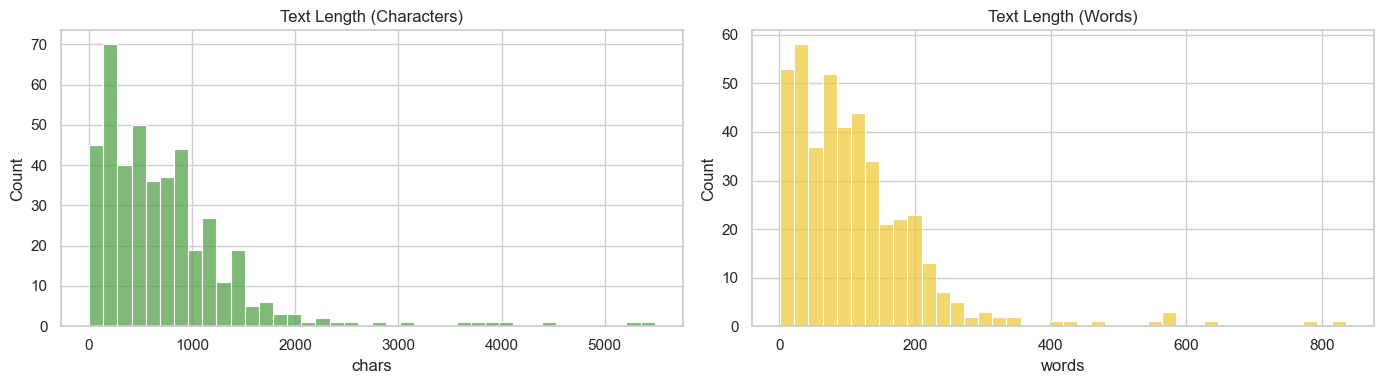

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['text_len_chars'], bins=40, ax=axes[0], color='#54A24B')
axes[0].set_title('Text Length (Characters)')
axes[0].set_xlabel('chars')

sns.histplot(df['text_len_words'], bins=40, ax=axes[1], color='#EECA3B')
axes[1].set_title('Text Length (Words)')
axes[1].set_xlabel('words')

plt.tight_layout()
plt.show()

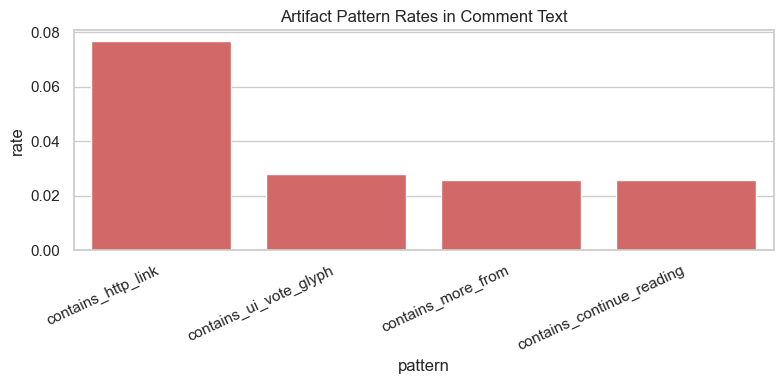

,rate
contains_http_link,0.076923
contains_ui_vote_glyph,0.027972
contains_more_from,0.025641
contains_continue_reading,0.025641


In [45]:
artifact_patterns = {
    'contains_continue_reading': r'Continue Reading',
    'contains_more_from': r'More from m/',
    'contains_http_link': r'https?://|\[http',
    'contains_ui_vote_glyph': r'\u25b2|\u25bc|▲|▼',
}

artifact_rates = {}
for name, pattern in artifact_patterns.items():
    artifact_rates[name] = df['text'].str.contains(pattern, regex=True, case=False, na=False).mean()

artifact_series = pd.Series(artifact_rates).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=artifact_series.index, y=artifact_series.values, color='#E45756')
plt.title('Artifact Pattern Rates in Comment Text')
plt.ylabel('rate')
plt.xlabel('pattern')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

artifact_series.to_frame('rate')